# Uniswap WETH/USDT clean closed position의 IL · LVR · PL

이 노트북은 원본 Uniswap/Binance 파일과 GitHub 코드를 **읽기만** 한다.
저장소 루트에서 실행하며, 계산 결과는 상대경로 `../../data_processing` 아래의
parquet 3개만 저장한다. 표와 그래프는 노트북 출력물로만 남긴다.

분석 기준

- 표본: clean closed position (단순히 Mint–Burn이라는 뜻이 아님)
- 평가통화: USDT, WETH 기준가격: Binance ETHUSDT 1초봉 close
- 포지션 inventory/in-range: Uniswap pool의 직전 Initialize/Swap tick
- 1초 결측: 직전 가격으로 forward-fill. 재개 시 가격변화는 한 번 반영
- 민감도: 관측 시각이 실제로 1초 연속인 가격변화만 사용
- fee: terminal return에서는 포함/제외를 모두 계산, 일별 IL/LVR/PL 경로에서는 제외
- gas: 모든 지표에서 제외
- risk-free rate: FRED의 일별 SOFR, 휴일은 직전 관측값 사용, ACT/360



In [1]:
from __future__ import annotations

import sys
import tempfile
from collections import defaultdict
from datetime import date
from pathlib import Path

import matplotlib
import numpy as np
import pandas as pd
import pandas_datareader.data as web
from IPython.display import display

matplotlib.use("module://matplotlib_inline.backend_inline")
import matplotlib.pyplot as plt


# 이 노트북은 Uniswap-ETH-risk-analysis 저장소 루트에서 실행한다.
REPOSITORY_ROOT = Path(".")
UNISWAP_ROOT = Path("../../../Data/uniswapdata")
BINANCE_1S_ROOT = Path("../../../Data/Binance_ETHUSDT_1s/parquet")
BINANCE_1M_PATH = Path("../../../Binance_data/processed_parquet/ETHUSDT_1m.parquet")
OUTPUT_ROOT = Path("../../data_processing")

DATASET_ID = "11b815ef_b12376751_b25779958"
POOL_ADDRESS = "0x11b815efb8f581194ae79006d24e0d814b7697f6"
NFPM_ADDRESS = "0xc36442b4a4522e871399cd717abdd847ab11fe88"
STUDY_START = date(2021, 5, 5)
STUDY_END_EXCLUSIVE = date(2026, 8, 19)

sys.path.insert(0, str(REPOSITORY_ROOT / "data" / "src"))

from uniswap_v3_data.events import parse_raw_events
from uniswap_v3_data.positions import (
    link_pool_mints_to_nfpm,
    reconstruct_positions_from_links,
)

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)
plt.style.use("seaborn-v0_8-whitegrid")



## 1. 원본 데이터 구조 확인

아래 DataFrame 출력은 계산 전에 실제 열과 시간형식을 눈으로 확인하기 위한 것이다.



In [2]:
uniswap_event_paths = sorted(
    (
        UNISWAP_ROOT
        / "raw"
        / "bigquery"
        / DATASET_ID
        / "events"
    ).glob("*.parquet")
)
binance_1s_paths = sorted(BINANCE_1S_ROOT.glob("*.parquet"))

data_inventory = pd.DataFrame(
    {
        "dataset": ["Uniswap raw events", "Binance ETHUSDT 1s", "Binance ETHUSDT 1m"],
        "path": [
            str(uniswap_event_paths[0].parent),
            str(BINANCE_1S_ROOT),
            str(BINANCE_1M_PATH),
        ],
        "file_count": [len(uniswap_event_paths), len(binance_1s_paths), 1],
    }
)
data_inventory



,dataset,path,file_count
0,Uniswap raw events,..\..\..\Data\uniswapdata\raw\bigquery\11b815ef_b12376751_b25779958\events,64
1,Binance ETHUSDT 1s,..\..\..\Data\Binance_ETHUSDT_1s\parquet,81
2,Binance ETHUSDT 1m,..\..\..\Binance_data\processed_parquet\ETHUSDT_1m.parquet,1


In [3]:
uniswap_events = pd.read_parquet(uniswap_event_paths[0])
uniswap_events



,block_number,block_timestamp,transaction_hash,transaction_index,log_index,address,topics_json,data,removed
0,12376751,2021-05-05 21:46:12+00:00,0x5399bd3a8fa539a1899af6b3c10a526d07e5c371a0c0bbcfde7c6cbffe88a59f,55,62,0x11b815efb8f581194ae79006d24e0d814b7697f6,"[""0x98636036cb66a9c19a37435efc1e90142190214e8abeb821bdba3f2990dd4c95""]",0x00000000000000000000000000000000000000000003d86fc50ede3fe8166202ffffffffff...,False
1,12376751,2021-05-05 21:46:12+00:00,0x5399bd3a8fa539a1899af6b3c10a526d07e5c371a0c0bbcfde7c6cbffe88a59f,55,66,0x11b815efb8f581194ae79006d24e0d814b7697f6,"[""0x7a53080ba414158be7ec69b987b5fb7d07dee101fe85488f0853ae16239d0bde"",""0x000...",0x000000000000000000000000c36442b4a4522e871399cd717abdd847ab11fe880000000000...,False
2,12376751,2021-05-05 21:46:12+00:00,0x5399bd3a8fa539a1899af6b3c10a526d07e5c371a0c0bbcfde7c6cbffe88a59f,55,67,0xc36442b4a4522e871399cd717abdd847ab11fe88,"[""0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef"",""0x000...",0x,False
3,12376751,2021-05-05 21:46:12+00:00,0x5399bd3a8fa539a1899af6b3c10a526d07e5c371a0c0bbcfde7c6cbffe88a59f,55,68,0xc36442b4a4522e871399cd717abdd847ab11fe88,"[""0x3067048beee31b25b2f1681f88dac838c8bba36af25bfb2b7cf7473a5847e35f"",""0x000...",0x00000000000000000000000000000000000000000000000000009cdffd1369a30000000000...,False
4,12376751,2021-05-05 21:46:12+00:00,0x5c45d34da3c871c84d768553a683028fd361defe92e5dc9b1769c260d82b502b,92,224,0xc36442b4a4522e871399cd717abdd847ab11fe88,"[""0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef"",""0x000...",0x,False
...,...,...,...,...,...,...,...,...,...
130074,12545210,2021-05-31 23:57:10+00:00,0x8643439507b66b908cc743ad1a00a77fe547628609f2797687ebd2c7d4598368,94,158,0xc36442b4a4522e871399cd717abdd847ab11fe88,"[""0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef"",""0x000...",0x,False
130075,12545210,2021-05-31 23:57:10+00:00,0x8643439507b66b908cc743ad1a00a77fe547628609f2797687ebd2c7d4598368,94,159,0xc36442b4a4522e871399cd717abdd847ab11fe88,"[""0x3067048beee31b25b2f1681f88dac838c8bba36af25bfb2b7cf7473a5847e35f"",""0x000...",0x000000000000000000000000000000000000000000000000000085f651c544070000000000...,False
130076,12545211,2021-05-31 23:57:26+00:00,0xce9273c3485354887d942b08f9e7bc9a9816410692c183c1019cf2edba183373,129,284,0xc36442b4a4522e871399cd717abdd847ab11fe88,"[""0xddf252ad1be2c89b69c2b068fc378daa952ba7f163c4a11628f55a4df523b3ef"",""0x000...",0x,False
130077,12545211,2021-05-31 23:57:26+00:00,0xce9273c3485354887d942b08f9e7bc9a9816410692c183c1019cf2edba183373,129,285,0xc36442b4a4522e871399cd717abdd847ab11fe88,"[""0x3067048beee31b25b2f1681f88dac838c8bba36af25bfb2b7cf7473a5847e35f"",""0x000...",0x0000000000000000000000000000000000000000000000f0c66f12220f1be5850000000000...,False


In [4]:
binance_ethusdt_1s = pd.read_parquet(binance_1s_paths[0])
binance_ethusdt_1s



,open_time,open,high,low,close,volume,close_time,quote_volume,trade_count,taker_buy_base_volume,taker_buy_quote_volume
0,2021-05-05 21:46:11+00:00,3437.31,3437.50,3436.84,3437.50,6.76079,2021-05-05 21:46:11.999000+00:00,23239.296881,22,0.74544,2562.341365
1,2021-05-05 21:46:12+00:00,3437.32,3437.50,3436.81,3437.31,11.54593,2021-05-05 21:46:12.999000+00:00,39686.497057,14,1.28706,4424.253927
2,2021-05-05 21:46:13+00:00,3437.31,3437.89,3436.86,3437.83,8.69011,2021-05-05 21:46:13.999000+00:00,29872.321284,17,6.69011,22998.376013
3,2021-05-05 21:46:14+00:00,3437.84,3437.88,3437.45,3437.45,6.17636,2021-05-05 21:46:14.999000+00:00,21233.173759,20,0.29950,1029.637588
4,2021-05-05 21:46:15+00:00,3437.51,3437.52,3436.70,3436.97,7.80836,2021-05-05 21:46:15.999000+00:00,26837.426777,24,0.68054,2339.369861
...,...,...,...,...,...,...,...,...,...,...,...
2254424,2021-05-31 23:59:55+00:00,2706.15,2706.50,2706.03,2706.42,33.32196,2021-05-31 23:59:55.999000+00:00,90173.010678,36,2.32983,6305.329504
2254425,2021-05-31 23:59:56+00:00,2706.46,2706.63,2706.03,2706.03,27.93207,2021-05-31 23:59:56.999000+00:00,75588.763585,39,4.27345,11566.048025
2254426,2021-05-31 23:59:57+00:00,2706.04,2706.14,2705.00,2705.00,84.36116,2021-05-31 23:59:57.999000+00:00,228266.281040,51,28.83113,78012.361530
2254427,2021-05-31 23:59:58+00:00,2704.77,2705.15,2704.55,2704.57,5.91282,2021-05-31 23:59:58.999000+00:00,15992.017524,17,1.36250,3685.179980


## 1-1. FRED SOFR 불러오기

`SOFR`는 FRED에서 percent 단위의 일별 연율로 제공된다. 발표가 없는 주말·휴일은
직전 영업일 rate가 적용되는 것으로 보고 달력일 grid에 forward-fill한다. 미국
money-market 관행에 맞춰 일별 단순 rate는 `SOFR / 100 / 360`으로 변환한다.
시작일 직전 영업일 값을 확보하기 위해 요청 시작일은 분석 시작 7일 전으로 둔다.



In [5]:
start_date = pd.Timestamp(STUDY_START) - pd.Timedelta(days=7)
end_date = pd.Timestamp(STUDY_END_EXCLUSIVE) - pd.Timedelta(days=1)

sofr_fred = web.DataReader("SOFR", "fred", start_date, end_date)
sofr_fred.index = pd.to_datetime(sofr_fred.index, utc=True)

sofr_calendar = pd.date_range(
    pd.Timestamp(STUDY_START, tz="UTC"),
    end_date.tz_localize("UTC"),
    freq="D",
)
sofr_daily = (
    sofr_fred.rename(columns={"SOFR": "sofr_percent"})
    .reindex(sofr_calendar)
    .ffill()
    .loc[pd.Timestamp(STUDY_START, tz="UTC") :]
)
sofr_daily["sofr_annual_decimal"] = sofr_daily["sofr_percent"] / 100.0
sofr_daily["sofr_daily_simple_rate"] = (
    sofr_daily["sofr_annual_decimal"] / 360.0
)
sofr_daily



,sofr_percent,sofr_annual_decimal,sofr_daily_simple_rate
2021-05-05 00:00:00+00:00,0.01,0.0001,2.777778e-07
2021-05-06 00:00:00+00:00,0.01,0.0001,2.777778e-07
2021-05-07 00:00:00+00:00,0.01,0.0001,2.777778e-07
2021-05-08 00:00:00+00:00,0.01,0.0001,2.777778e-07
2021-05-09 00:00:00+00:00,0.01,0.0001,2.777778e-07
...,...,...,...
2026-08-14 00:00:00+00:00,3.62,0.0362,1.005556e-04
2026-08-15 00:00:00+00:00,3.62,0.0362,1.005556e-04
2026-08-16 00:00:00+00:00,3.62,0.0362,1.005556e-04
2026-08-17 00:00:00+00:00,3.66,0.0366,1.016667e-04


## 2. clean closed position 재구성

여기서 clean closed는 `min burn`이나 단순 Mint–Burn을 뜻하지 않는다. 이 pool과
연결된 NFT position 가운데 다음을 모두 만족하는 엄격한 표본이다.

- pool Mint 1회와 NFPM IncreaseLiquidity 1회가 정확히 연결됨
- IncreaseLiquidity 1회, DecreaseLiquidity 1회
- NFT creation 1회, NFT burn 1회, 중간 ownership transfer 0회
- Collect 1회 이상, 전 liquidity 회수, 단일 range
- fee가 음수가 아니고 entry → exit → settlement 순서가 유효
- entry/exit/settlement가 분석기간 안에 있음

원본 월별 event는 GitHub의 decoder로 읽고, 필요한 NFPM lifecycle과 pool tick만
임시폴더에 보관한다. 임시파일은 마지막 셀에서 삭제된다.



In [6]:
scratch = tempfile.TemporaryDirectory(prefix="fp_challenge_analysis_")
scratch_root = Path(scratch.name)
links_by_month = []
pool_state_paths = {}
decode_progress = []

for month_number, raw_path in enumerate(uniswap_event_paths, start=1):
    raw = pd.read_parquet(raw_path)
    pool_events, nfpm_events = parse_raw_events(raw, POOL_ADDRESS, NFPM_ADDRESS)
    links = link_pool_mints_to_nfpm(pool_events, nfpm_events, NFPM_ADDRESS)
    month_key = raw_path.stem.split("_")[1][:7]

    links_by_month.append(links)
    nfpm_events.to_parquet(
        scratch_root / f"nfpm_{month_key}.parquet",
        index=False,
        compression="zstd",
    )

    pool_state = (
        pool_events.loc[
            pool_events["event_type"].isin(["Initialize", "Swap"]),
            [
                "block_timestamp",
                "block_number",
                "transaction_index",
                "log_index",
                "tick",
            ],
        ]
        .sort_values(
            ["block_number", "transaction_index", "log_index"], kind="stable"
        )
        .reset_index(drop=True)
    )
    pool_state_path = scratch_root / f"pool_state_{month_key}.parquet"
    pool_state.to_parquet(pool_state_path, index=False, compression="zstd")
    pool_state_paths[month_key] = pool_state_path

    decode_progress.append(
        {
            "month": month_key,
            "pool_events": len(pool_events),
            "nfpm_events": len(nfpm_events),
            "matched_mints": len(links),
        }
    )
    if month_number == 1 or month_number % 12 == 0 or month_number == len(uniswap_event_paths):
        print(f"decoded {month_number:02d}/{len(uniswap_event_paths)} months")

links = pd.concat(links_by_month, ignore_index=True)
target_ids = set(links["token_id"].astype(str))
target_lifecycle = []

for nfpm_path in sorted(scratch_root.glob("nfpm_*.parquet")):
    nfpm_events = pd.read_parquet(nfpm_path)
    selected = nfpm_events.loc[nfpm_events["token_id"].astype(str).isin(target_ids)]
    if not selected.empty:
        target_lifecycle.append(selected)

target_events = pd.concat(target_lifecycle, ignore_index=True)
all_target_positions, clean_closed_positions = reconstruct_positions_from_links(
    links,
    target_events,
    STUDY_START,
    STUDY_END_EXCLUSIVE,
)

OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)
clean_closed_positions.to_parquet(
    OUTPUT_ROOT / "clean_closed_positions.parquet",
    index=False,
    compression="zstd",
)

reconstruction_summary = pd.DataFrame(
    {
        "matched_pool_mints": [len(links)],
        "target_nfpm_events": [len(target_events)],
        "target_positions": [len(all_target_positions)],
        "clean_closed_positions": [len(clean_closed_positions)],
    }
)
reconstruction_summary



decoded 01/64 months


decoded 12/64 months


decoded 24/64 months


decoded 36/64 months


decoded 48/64 months


decoded 60/64 months


decoded 64/64 months


,matched_pool_mints,target_nfpm_events,target_positions,clean_closed_positions
0,19756,75173,14073,1164


In [7]:
clean_closed_positions



,token_id,initial_owner,tick_lower,tick_upper,entry_block,entry_timestamp,entry_transaction_hash,exit_block,exit_timestamp,exit_transaction_hash,settlement_block,settlement_timestamp,increase_count,decrease_count,collect_count,creation_count,burn_count,ownership_transfer_count,matched_pool_mint_count,liquidity_increased_raw,liquidity_decreased_raw,liquidity_remaining_raw,deposit_amount0_raw,deposit_amount1_raw,withdraw_principal0_raw,withdraw_principal1_raw,collected_amount0_raw,collected_amount1_raw,fee_amount0_raw,fee_amount1_raw,is_fully_withdrawn,is_nft_burned,is_fee_complete_proven,has_unique_range,has_nonnegative_fee,entry_in_study_window,exit_in_study_window,settlement_in_study_window,has_valid_event_order,is_clean_closed
0,43032,0x61c808d82a3ac53231750dadc13c777b59310bd9,-199800,-198600,12609096,2021-06-10 20:59:06+00:00,0x3cfc1f9447348615d3509fed8291f0947b0abe74857277b8e0339b255476b854,12629754.0,2021-06-14 01:46:25+00:00,0x2ccb68e4337cc67aebaaa7967a21364bbf12c660e4f53d4f9e881361b672501b,12629788.0,2021-06-14 01:55:54+00:00,1,1,1,1,1,0,1,352502420321723597,352502420321723597,0,0,1000000000000,0,999999999999,1642010261468762855,1003817936449,1642010261468762855,3817936450,True,True,True,True,True,True,True,True,True,True
1,44929,0x9799b475dec92bd99bbdd943013325c36157f383,-198510,-198500,12619579,2021-06-12 12:12:19+00:00,0x2e784c317518c718d421c7e5347c5609d296b5a9bf1c5d599eca4c490365a76b,12619579.0,2021-06-12 12:12:19+00:00,0x9bf7f089795ea0ff498a051bd88b5d4818a0edd14621abef5862110fe1d1e80e,12619579.0,2021-06-12 12:12:19+00:00,1,1,1,1,1,0,1,3268944060035945759,3268944060035945759,0,0,79999999999,2848817607876838895,73171400250,2850242729241459625,73171400250,1425121364620730,0,True,True,True,True,True,True,True,True,True,True
2,45713,0x9799b475dec92bd99bbdd943013325c36157f383,-198830,-198820,12624466,2021-06-13 06:23:28+00:00,0x8c433e7bb34878ceb25f3f149105f793149fff0662b4b856b1864ff4d92f8e6f,12624466.0,2021-06-13 06:23:28+00:00,0x898a76f9f17ab213c3669d6905105c3a43a098628e4b4e424d35ba80014d896e,12624466.0,2021-06-13 06:23:28+00:00,1,1,1,1,1,0,1,4701853291350109926,4701853291350109926,0,0,113240872781,10311259962152520920,89304702682,10316418171238139990,89304702682,5158209085619070,0,True,True,True,True,True,True,True,True,True,True
3,47324,0x9799b475dec92bd99bbdd943013325c36157f383,-197760,-197750,12633129,2021-06-14 14:33:46+00:00,0xa3b47c8e0fe806cbf741ac5adf10cb2bf9753bb75ace69c15735e9d6ef04f188,12633129.0,2021-06-14 14:33:46+00:00,0xa8916146b05b5647379fe0fc8a82c1d5bf96368790d8860f4bae4009e6208c98,12633129.0,2021-06-14 14:33:46+00:00,1,1,1,1,1,0,1,13375417312160776674,13375417312160776674,0,131594035066032115568,0,112837620402821226265,48417514963,112837620402821226265,48441735831,0,24220868,True,True,True,True,True,True,True,True,True,True
4,53064,0x7ebe212f25336c12e8434bc55687485bdd669304,-230280,-154250,12664430,2021-06-19 11:05:48+00:00,0x4c84071e7a411f6b12135c4b9a525b6b39653fc5551cd03d71abb11701306aa1,22036191.0,2025-03-13 06:34:59+00:00,0x848f41398845cfea5f490ee9b12e8eed9d4c4ba52456797fc3e0ad6c32cd9b00,22036191.0,2025-03-13 06:34:59+00:00,1,1,11,1,1,0,1,32003584930518,32003584930518,0,606488355040047241,1190731415,669539599733944288,1062207907,859807815588949603,1444879911,190268215855005315,382672004,True,True,True,True,True,True,True,True,True,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1159,1350746,0x0b5fb31c685a11e06de9cdad4113f89f9505ec9c,-200830,-200710,25772801,2026-08-17 05:47:11+00:00,0x18234a46e65c47182e690e56c6df000b34aca1f13d6cf6868156110132ace165,25773505.0,2026-08-17 08:08:11+00:00,0xd33e6a29a5b6eda6ecea4a5556ecd8d27418925528ebf542b9ce4b2425ab530a,25773505.0,2026-08-17 08:08:11+00:00,1,1,1,1,1,0,1,19158577877612728,19158577877612728,0,2629908534786193086,0,2629908534786193085,0,2631328905824965076,2706402,1420371038771991,2706402,True,True,True,True,True,True,True,True,True,Tr

## 3. 수식과 부호

### Inventory와 IL

token0=WETH, token1=USDT이고 human price를 $P=$ USDT/WETH로 둔다.
현재 pool tick을 position range로 clamp한 가격을 $P_c$라 하면

$$x_t=L\left(\frac{1}{\sqrt{P_c}}-\frac{1}{\sqrt{P_u}}\right),\qquad
y_t=L\left(\sqrt{P_c}-\sqrt{P_l}\right).$$

$$IL_t=\frac{x_tP_t^{CEX}+y_t-
(x_0P_t^{CEX}+y_0)}{x_0P_t^{CEX}+y_0}.$$

terminal IL은 theoretical inventory가 아니라 실제 DecreaseLiquidity principal로
한 번 더 계산한다. fee와 gas는 IL에서 제외한다.

### LVR

[Milionis et al.](https://arxiv.org/abs/2208.06046)의 quadratic-variation
근사를 1초 간격으로 이산화한다.

$$\Delta LVR_t \approx
\mathbf{1}_{\{tick_{t-1}\in[tick_l,tick_u)\}}
\frac{L}{4(P_{t-1}^{CEX})^{3/2}}(\Delta P_t^{CEX})^2.$$

기본값은 forward-fill 뒤 재개가격 점프를 한 번 포함한다. 민감도 값은 두
시각이 모두 실제로 관측된 연속 1초인 경우만 포함한다. 별도로 직전 on-chain
inventory를 계속 보유하는 rebalancing 전략의 손익을 계산해 검산값으로 둔다.

### Predictable Loss (PL)

[Cartea, Drissi and Monga](https://papers.ssrn.com/sol3/papers.cfm?abstract_id=4541034)의
concentrated-liquidity PL 식에서 $r=0$인 convexity/QV 항은 같은 가정 아래
LVR의 음수 부호와 대응한다.

$$realized\ core\ PL_{r=0}=-LVR.$$

사전 30일 일별 log-return 변동성을 $\sigma$, 보유기간을 $T$라 할 때 논문의
고정 spread 근사도 함께 기록한다.

$$\frac{E[PL_T]}{\alpha_0}=\frac{1}{\delta}
\left(e^{-\sigma^2T/8}-1\right).$$

여기에 FRED의 일별 SOFR로 계산한 risk-free opportunity cost를 별도 차감한다.
기존 staking 분석과 비교할 수 있도록 노출 기준은 그대로 동적인 WETH inventory의
USDT 평가액으로 두고, SOFR를 ACT/360 방식으로 초 단위 적용한다. 이는 논문의
$r=0$ core PL에 실증적인 현금 기회비용을 추가한 확장값이다.

$$SOFR\ adjusted\ PL=realized\ core\ PL_{r=0}
-SOFR\ opportunity\ cost.$$

데이터 출처: [FRED SOFR](https://fred.stlouisfed.org/series/SOFR), 원자료 제공기관은
Federal Reserve Bank of New York이다.



## 4. 1초 단위 계산 함수

1초 가격을 position 수만큼 복제하지 않는다. 월별로 완전한 1초 grid를 만든 뒤,
하루의 값을 pool tick별로 합산하고 position range에 필요한 부분만 누적한다.
entry second 이전의 가격변화는 포함하지 않으며 position은
`[entry second, exit second)` 동안 보유한 것으로 처리한다. 같은 초 안의 정확한
log 순서는 block event에는 존재하지만 Binance 1초봉에는 없으므로 그 이하의
순서는 식별할 수 없다.



In [8]:
NANOSECONDS_PER_SECOND = 1_000_000_000
SECONDS_PER_DAY = 86_400


def tick_price(tick):
    """Uniswap raw tick을 human USDT/WETH 가격으로 변환한다."""
    return np.power(1.0001, np.asarray(tick, dtype=float)) * 1e12


def unit_inventory(ticks, tick_lower, tick_upper):
    """human liquidity 1당 WETH/USDT inventory."""
    ticks = np.asarray(ticks, dtype=float)
    bounded_tick = np.clip(ticks, tick_lower, tick_upper)
    price = tick_price(bounded_tick)
    lower_price = float(tick_price(tick_lower))
    upper_price = float(tick_price(tick_upper))
    weth = 1.0 / np.sqrt(price) - 1.0 / np.sqrt(upper_price)
    usdt = np.sqrt(price) - np.sqrt(lower_price)
    return weth, usdt


def grouped_tick_sums(ticks, **values):
    """한 시간구간의 값을 pool tick별로 합친다."""
    finite = np.isfinite(ticks)
    integer_ticks = np.asarray(ticks[finite], dtype=np.int32)
    unique_ticks, inverse = np.unique(integer_ticks, return_inverse=True)
    sums = {
        name: np.bincount(inverse, weights=np.asarray(value)[finite])
        for name, value in values.items()
    }
    return unique_ticks, sums


def integrate_lvr_group(group, tick_lower, tick_upper, liquidity):
    ticks, sums = group
    in_range = (ticks >= tick_lower) & (ticks < tick_upper)
    weth_per_liquidity, _ = unit_inventory(ticks, tick_lower, tick_upper)
    return (
        liquidity * sums["lvr_base"][in_range].sum(),
        liquidity * sums["lvr_base_gap_excluded"][in_range].sum(),
        liquidity * np.dot(weth_per_liquidity, sums["price_change"]),
    )


def integrate_sofr_group(group, tick_lower, tick_upper, liquidity):
    ticks, sums = group
    weth_per_liquidity, _ = unit_inventory(ticks, tick_lower, tick_upper)
    return liquidity * np.dot(weth_per_liquidity, sums["sofr_marked_weth_value"])


def binance_month_key(path):
    parts = path.stem.split("-")
    return f"{parts[2]}-{parts[3]}"


def weighted_average(group, value_column):
    valid = group[value_column].notna() & group["initial_wealth_usdt"].gt(0)
    weights = group.loc[valid, "initial_wealth_usdt"]
    return np.average(group.loc[valid, value_column], weights=weights) if valid.any() else np.nan


def calculate_one_second_metrics(clean_positions, binance_paths, pool_paths, sofr_rates):
    positions = clean_positions.copy().reset_index(drop=True)
    position_count = len(positions)

    entry_time = pd.DatetimeIndex(pd.to_datetime(positions["entry_timestamp"], utc=True))
    exit_time = pd.DatetimeIndex(pd.to_datetime(positions["exit_timestamp"], utc=True))
    entry_ns = entry_time.as_unit("ns").asi8
    exit_ns = exit_time.as_unit("ns").asi8

    tick_lower = positions["tick_lower"].to_numpy(dtype=np.int32)
    tick_upper = positions["tick_upper"].to_numpy(dtype=np.int32)
    liquidity = positions["liquidity_increased_raw"].map(float).to_numpy() * 1e-12
    deposit_weth = positions["deposit_amount0_raw"].map(float).to_numpy() / 1e18
    deposit_usdt = positions["deposit_amount1_raw"].map(float).to_numpy() / 1e6
    principal_weth = positions["withdraw_principal0_raw"].map(float).to_numpy() / 1e18
    principal_usdt = positions["withdraw_principal1_raw"].map(float).to_numpy() / 1e6
    fee_weth = positions["fee_amount0_raw"].map(float).to_numpy() / 1e18
    fee_usdt = positions["fee_amount1_raw"].map(float).to_numpy() / 1e6

    price_entry = np.full(position_count, np.nan)
    price_exit = np.full(position_count, np.nan)
    pool_tick_entry = np.full(position_count, np.nan)
    pool_tick_exit = np.full(position_count, np.nan)
    lvr_qv = np.zeros(position_count)
    lvr_qv_gap_excluded = np.zeros(position_count)
    rebalancing_gain = np.zeros(position_count)
    sofr_opportunity_cost = np.zeros(position_count)

    price_files_by_month = defaultdict(list)
    for path in binance_paths:
        price_files_by_month[binance_month_key(path)].append(path)

    first_price = pd.read_parquet(binance_paths[0], columns=["open_time"]).iloc[0, 0]
    last_price_frame = pd.read_parquet(binance_paths[-1], columns=["open_time"])
    analysis_start = pd.Timestamp(first_price).floor("s")
    analysis_end = pd.Timestamp(last_price_frame.iloc[-1, 0]).floor("s")

    previous_price = np.nan
    previous_observed = True
    previous_pool_tick = np.nan
    missing_rows = []
    market_daily_rows = []
    position_daily_rows = []

    for month_number, month_key in enumerate(sorted(price_files_by_month), start=1):
        month_start = pd.Timestamp(f"{month_key}-01", tz="UTC")
        next_month = month_start + pd.offsets.MonthBegin(1)
        grid_start = max(month_start, analysis_start)
        grid_end = min(next_month - pd.Timedelta(seconds=1), analysis_end)
        grid = pd.date_range(grid_start, grid_end, freq="s")
        grid_ns = grid.as_unit("ns").asi8

        price_frame = pd.concat(
            [
                pd.read_parquet(path, columns=["open_time", "close"])
                for path in price_files_by_month[month_key]
            ],
            ignore_index=True,
        )
        raw_price = (
            price_frame.sort_values("open_time", kind="stable")
            .drop_duplicates("open_time", keep="last")
            .set_index("open_time")["close"]
            .reindex(grid)
        )
        observed = raw_price.notna().to_numpy()
        filled_price = raw_price.ffill()
        if np.isfinite(previous_price):
            filled_price = filled_price.fillna(previous_price)
        price = filled_price.to_numpy(dtype=float)

        pool_state = pd.read_parquet(pool_paths[month_key])
        pool_state["second"] = pool_state["block_timestamp"].dt.floor("s")
        pool_second = (
            pool_state.sort_values(
                ["block_number", "transaction_index", "log_index"], kind="stable"
            )
            .drop_duplicates("second", keep="last")
            .set_index("second")["tick"]
            .reindex(grid)
            .ffill()
        )
        if np.isfinite(previous_pool_tick):
            pool_second = pool_second.fillna(previous_pool_tick)
        pool_tick = pool_second.to_numpy(dtype=float)
        sofr_rate_per_second = (
            sofr_rates["sofr_annual_decimal"]
            .reindex(grid.normalize())
            .to_numpy(dtype=float)
            / 360.0
            / SECONDS_PER_DAY
        )

        price_previous = np.empty_like(price)
        price_previous[0] = previous_price if np.isfinite(previous_price) else price[0]
        price_previous[1:] = price[:-1]
        observed_previous = np.empty_like(observed)
        observed_previous[0] = previous_observed
        observed_previous[1:] = observed[:-1]
        pool_tick_previous = np.empty_like(pool_tick)
        pool_tick_previous[0] = (
            previous_pool_tick if np.isfinite(previous_pool_tick) else pool_tick[0]
        )
        pool_tick_previous[1:] = pool_tick[:-1]

        price_change = price - price_previous
        lvr_base = price_change**2 / (4.0 * np.power(price_previous, 1.5))
        consecutive_observation = observed & observed_previous
        lvr_base_gap_excluded = np.where(consecutive_observation, lvr_base, 0.0)

        month_entry = np.flatnonzero((entry_ns >= grid_ns[0]) & (entry_ns <= grid_ns[-1]))
        month_exit = np.flatnonzero((exit_ns >= grid_ns[0]) & (exit_ns <= grid_ns[-1]))
        entry_offsets = ((entry_ns[month_entry] - grid_ns[0]) // NANOSECONDS_PER_SECOND).astype(int)
        exit_offsets = ((exit_ns[month_exit] - grid_ns[0]) // NANOSECONDS_PER_SECOND).astype(int)
        price_entry[month_entry] = price[entry_offsets]
        price_exit[month_exit] = price[exit_offsets]
        pool_tick_entry[month_entry] = pool_tick[entry_offsets]
        pool_tick_exit[month_exit] = pool_tick[exit_offsets]

        missing_rows.append(
            {
                "month": month_start,
                "expected_seconds": len(grid),
                "observed_seconds": int(observed.sum()),
                "forward_filled_seconds": int((~observed).sum()),
            }
        )

        for day_start in pd.date_range(grid[0].normalize(), grid[-1].normalize(), freq="D"):
            day_end = day_start + pd.Timedelta(days=1)
            slice_start = max(day_start, grid_start)
            slice_end = min(day_end, grid_end + pd.Timedelta(seconds=1))
            slice_start_ns = slice_start.value
            slice_end_ns = slice_end.value
            day_start_ns = day_start.value
            day_end_ns = day_end.value
            i0 = int((slice_start_ns - grid_ns[0]) // NANOSECONDS_PER_SECOND)
            i1 = int((slice_end_ns - grid_ns[0]) // NANOSECONDS_PER_SECOND)

            market_daily_rows.append(
                {"date": day_start, "ethusdt_close": price[i1 - 1]}
            )
            active = np.flatnonzero((entry_ns < day_end_ns) & (exit_ns >= day_start_ns))
            if len(active) == 0:
                continue

            full_lvr_group = grouped_tick_sums(
                pool_tick_previous[i0:i1],
                lvr_base=lvr_base[i0:i1],
                lvr_base_gap_excluded=lvr_base_gap_excluded[i0:i1],
                price_change=price_change[i0:i1],
            )
            full_sofr_group = grouped_tick_sums(
                pool_tick[i0:i1],
                sofr_marked_weth_value=(
                    price[i0:i1] * sofr_rate_per_second[i0:i1]
                ),
            )

            for position_index in active:
                sofr_start_ns = max(entry_ns[position_index], slice_start_ns)
                sofr_end_ns = min(exit_ns[position_index], slice_end_ns)
                sofr_start = int(
                    (sofr_start_ns - grid_ns[0]) // NANOSECONDS_PER_SECOND
                )
                sofr_end = int(
                    (sofr_end_ns - grid_ns[0]) // NANOSECONDS_PER_SECOND
                )

                if sofr_end > sofr_start:
                    sofr_group = (
                        full_sofr_group
                        if sofr_start == i0 and sofr_end == i1
                        else grouped_tick_sums(
                            pool_tick[sofr_start:sofr_end],
                            sofr_marked_weth_value=(
                                price[sofr_start:sofr_end]
                                * sofr_rate_per_second[sofr_start:sofr_end]
                            ),
                        )
                    )
                    sofr_opportunity_cost[position_index] += integrate_sofr_group(
                        sofr_group,
                        tick_lower[position_index],
                        tick_upper[position_index],
                        liquidity[position_index],
                    )

                lvr_start_ns = max(
                    entry_ns[position_index] + NANOSECONDS_PER_SECOND,
                    slice_start_ns,
                )
                lvr_end_ns = min(exit_ns[position_index], slice_end_ns)
                lvr_start = int(
                    (lvr_start_ns - grid_ns[0]) // NANOSECONDS_PER_SECOND
                )
                lvr_end = int((lvr_end_ns - grid_ns[0]) // NANOSECONDS_PER_SECOND)

                if lvr_end > lvr_start:
                    lvr_group = (
                        full_lvr_group
                        if lvr_start == i0 and lvr_end == i1
                        else grouped_tick_sums(
                            pool_tick_previous[lvr_start:lvr_end],
                            lvr_base=lvr_base[lvr_start:lvr_end],
                            lvr_base_gap_excluded=lvr_base_gap_excluded[lvr_start:lvr_end],
                            price_change=price_change[lvr_start:lvr_end],
                        )
                    )
                    qv, qv_gap_excluded, gain = integrate_lvr_group(
                        lvr_group,
                        tick_lower[position_index],
                        tick_upper[position_index],
                        liquidity[position_index],
                    )
                    lvr_qv[position_index] += qv
                    lvr_qv_gap_excluded[position_index] += qv_gap_excluded
                    rebalancing_gain[position_index] += gain

                initial_wealth = (
                    deposit_weth[position_index] * price_entry[position_index]
                    + deposit_usdt[position_index]
                )
                if exit_ns[position_index] <= day_end_ns:
                    snapshot_price = price_exit[position_index]
                    lp_principal = (
                        principal_weth[position_index] * snapshot_price
                        + principal_usdt[position_index]
                    )
                else:
                    snapshot_index = i1 - 1
                    snapshot_price = price[snapshot_index]
                    weth_unit, usdt_unit = unit_inventory(
                        np.array([pool_tick[snapshot_index]]),
                        tick_lower[position_index],
                        tick_upper[position_index],
                    )
                    lp_principal = liquidity[position_index] * (
                        weth_unit[0] * snapshot_price + usdt_unit[0]
                    )
                hodl_value = (
                    deposit_weth[position_index] * snapshot_price
                    + deposit_usdt[position_index]
                )
                il_return = (lp_principal - hodl_value) / hodl_value

                position_daily_rows.append(
                    {
                        "date": day_start,
                        "token_id": positions.loc[position_index, "token_id"],
                        "initial_wealth_usdt": initial_wealth,
                        "il_loss_fraction": -il_return,
                        "lvr_loss_fraction": lvr_qv[position_index] / initial_wealth,
                        "lvr_gap_excluded_loss_fraction": (
                            lvr_qv_gap_excluded[position_index] / initial_wealth
                        ),
                        "realized_core_pl_r0_fraction": (
                            -lvr_qv[position_index] / initial_wealth
                        ),
                        "sofr_opportunity_cost_fraction": (
                            sofr_opportunity_cost[position_index] / initial_wealth
                        ),
                        "sofr_adjusted_pl_fraction": (
                            -(
                                lvr_qv[position_index]
                                + sofr_opportunity_cost[position_index]
                            )
                            / initial_wealth
                        ),
                    }
                )

        previous_price = price[-1]
        previous_observed = bool(observed[-1])
        previous_pool_tick = pool_tick[-1]
        if month_number == 1 or month_number % 12 == 0 or month_number == len(price_files_by_month):
            print(f"calculated {month_number:02d}/{len(price_files_by_month)} months")

    missing_by_month = pd.DataFrame(missing_rows)
    market_daily = (
        pd.DataFrame(market_daily_rows)
        .sort_values("date", kind="stable")
        .drop_duplicates("date", keep="last")
        .reset_index(drop=True)
    )
    position_daily = pd.DataFrame(position_daily_rows)

    initial_wealth = deposit_weth * price_entry + deposit_usdt
    principal_exit_value = principal_weth * price_exit + principal_usdt
    fee_exit_value = fee_weth * price_exit + fee_usdt
    lp_exit_value = principal_exit_value + fee_exit_value
    hodl_exit_value = deposit_weth * price_exit + deposit_usdt
    rebalancing_value = initial_wealth + rebalancing_gain

    positions["holding_seconds"] = (exit_ns - entry_ns) / NANOSECONDS_PER_SECOND
    positions["holding_days"] = positions["holding_seconds"] / SECONDS_PER_DAY
    positions["binance_price_entry_usdt"] = price_entry
    positions["binance_price_exit_usdt"] = price_exit
    positions["pool_tick_entry"] = pd.array(pool_tick_entry, dtype="Int64")
    positions["pool_tick_exit"] = pd.array(pool_tick_exit, dtype="Int64")
    positions["pool_price_entry_usdt"] = tick_price(pool_tick_entry)
    positions["pool_price_exit_usdt"] = tick_price(pool_tick_exit)
    positions["deposit_weth"] = deposit_weth
    positions["deposit_usdt"] = deposit_usdt
    positions["withdraw_principal_weth"] = principal_weth
    positions["withdraw_principal_usdt"] = principal_usdt
    positions["fee_weth"] = fee_weth
    positions["fee_usdt"] = fee_usdt
    positions["initial_wealth_usdt"] = initial_wealth
    positions["principal_exit_value_usdt"] = principal_exit_value
    positions["fee_exit_value_usdt"] = fee_exit_value
    positions["lp_exit_value_usdt"] = lp_exit_value
    positions["hodl_exit_value_usdt"] = hodl_exit_value
    positions["terminal_return_fee_inclusive"] = (
        lp_exit_value - initial_wealth
    ) / initial_wealth
    positions["terminal_return_fee_exclusive"] = (
        principal_exit_value - initial_wealth
    ) / initial_wealth
    positions["terminal_excess_return_vs_hodl_fee_inclusive"] = (
        lp_exit_value - hodl_exit_value
    ) / hodl_exit_value
    positions["il_return_vs_hodl_fee_exclusive"] = (
        principal_exit_value - hodl_exit_value
    ) / hodl_exit_value
    positions["il_loss_fraction_terminal"] = -positions[
        "il_return_vs_hodl_fee_exclusive"
    ]
    positions["fee_return_on_initial_wealth"] = fee_exit_value / initial_wealth
    positions["lvr_qv_usdt"] = lvr_qv
    positions["lvr_qv_fraction_initial"] = lvr_qv / initial_wealth
    positions["lvr_qv_gap_excluded_usdt"] = lvr_qv_gap_excluded
    positions["lvr_qv_gap_excluded_fraction_initial"] = (
        lvr_qv_gap_excluded / initial_wealth
    )
    positions["rebalancing_strategy_value_usdt"] = rebalancing_value
    positions["lvr_direct_validation_usdt"] = (
        rebalancing_value - principal_exit_value
    )
    positions["lvr_direct_validation_fraction_initial"] = (
        positions["lvr_direct_validation_usdt"] / initial_wealth
    )
    positions["realized_core_pl_r0_usdt"] = -lvr_qv
    positions["realized_core_pl_r0_fraction_initial"] = -lvr_qv / initial_wealth
    positions["sofr_percent_at_entry"] = sofr_rates["sofr_percent"].reindex(
        entry_time.normalize()
    ).to_numpy(dtype=float)
    positions["sofr_opportunity_cost_usdt"] = sofr_opportunity_cost
    positions["sofr_opportunity_cost_fraction_initial"] = (
        sofr_opportunity_cost / initial_wealth
    )
    positions["sofr_adjusted_pl_usdt"] = -lvr_qv - sofr_opportunity_cost
    positions["sofr_adjusted_pl_fraction_initial"] = (
        positions["sofr_adjusted_pl_usdt"] / initial_wealth
    )

    one_minute = pd.read_parquet(BINANCE_1M_PATH, columns=["close"])
    one_minute.index = pd.to_datetime(one_minute.index, utc=True)
    daily_close_1m = one_minute["close"].sort_index().resample("D").last().dropna()
    daily_close_1s = market_daily.set_index("date")["ethusdt_close"]
    daily_close = pd.concat(
        [daily_close_1m, daily_close_1s.loc[daily_close_1s.index > daily_close_1m.index.max()]]
    ).sort_index()
    prior_volatility = np.log(daily_close).diff().rolling(30).std().shift(1)
    entry_dates = entry_time.normalize()
    sigma_daily = prior_volatility.reindex(entry_dates).to_numpy(dtype=float)

    entry_pool_price = tick_price(pool_tick_entry)
    lower_price = tick_price(tick_lower)
    upper_price = tick_price(tick_upper)
    expected_pl_applicable = (
        (entry_pool_price >= lower_price) & (entry_pool_price <= upper_price)
    )
    delta_lower = 2.0 * (1.0 - np.sqrt(lower_price / entry_pool_price))
    delta_upper = 2.0 * (1.0 - np.sqrt(entry_pool_price / upper_price))
    delta_total = delta_lower + delta_upper
    expected_pl_fraction = np.full(position_count, np.nan)
    expected_pl_fraction[expected_pl_applicable] = (
        np.exp(
            -(sigma_daily[expected_pl_applicable] ** 2)
            * positions.loc[expected_pl_applicable, "holding_days"].to_numpy()
            / 8.0
        )
        - 1.0
    ) / delta_total[expected_pl_applicable]

    positions["pre_entry_volatility_30d_daily"] = sigma_daily
    positions["pre_entry_volatility_30d_annualized"] = sigma_daily * np.sqrt(365.0)
    positions["pl_delta_lower"] = delta_lower
    positions["pl_delta_upper"] = delta_upper
    positions["pl_delta_total"] = delta_total
    positions["expected_pl_formula_applicable"] = expected_pl_applicable
    positions["expected_core_pl_r0_fraction_initial"] = expected_pl_fraction
    positions["expected_core_pl_r0_usdt"] = expected_pl_fraction * initial_wealth

    aggregate_rows = []
    for day, group in position_daily.groupby("date", sort=True):
        aggregate_rows.append(
            {
                "date": day,
                "position_day_count": group["token_id"].nunique(),
                "initial_capital_usdt": group["initial_wealth_usdt"].sum(),
                "capital_weighted_il_loss_pct": 100
                * weighted_average(group, "il_loss_fraction"),
                "capital_weighted_lvr_loss_pct": 100
                * weighted_average(group, "lvr_loss_fraction"),
                "capital_weighted_lvr_gap_excluded_loss_pct": 100
                * weighted_average(group, "lvr_gap_excluded_loss_fraction"),
                "capital_weighted_realized_core_pl_r0_pct": 100
                * weighted_average(group, "realized_core_pl_r0_fraction"),
                "capital_weighted_sofr_opportunity_cost_pct": 100
                * weighted_average(group, "sofr_opportunity_cost_fraction"),
                "capital_weighted_sofr_adjusted_pl_pct": 100
                * weighted_average(group, "sofr_adjusted_pl_fraction"),
                "capital_weighted_sofr_adjusted_pl_loss_pct": -100
                * weighted_average(group, "sofr_adjusted_pl_fraction"),
            }
        )

    aggregate_daily = pd.DataFrame(aggregate_rows)
    portfolio_daily = market_daily.merge(aggregate_daily, on="date", how="left")
    portfolio_daily["position_day_count"] = (
        portfolio_daily["position_day_count"].fillna(0).astype(int)
    )
    portfolio_daily["initial_capital_usdt"] = portfolio_daily[
        "initial_capital_usdt"
    ].fillna(0.0)
    portfolio_daily["sofr_percent"] = sofr_rates["sofr_percent"].reindex(
        pd.DatetimeIndex(portfolio_daily["date"])
    ).to_numpy(dtype=float)

    return positions, portfolio_daily, missing_by_month



In [9]:
position_lifetime_metrics, clean_position_portfolio_daily, missing_by_month = (
    calculate_one_second_metrics(
        clean_closed_positions,
        binance_1s_paths,
        pool_state_paths,
        sofr_daily,
    )
)

position_lifetime_metrics.to_parquet(
    OUTPUT_ROOT / "position_lifetime_metrics.parquet",
    index=False,
    compression="zstd",
)
clean_position_portfolio_daily.to_parquet(
    OUTPUT_ROOT / "clean_position_portfolio_daily.parquet",
    index=False,
    compression="zstd",
)

calculation_summary = pd.DataFrame(
    {
        "metric": [
            "clean positions",
            "analysis start (UTC)",
            "analysis end (UTC)",
            "forward-filled seconds",
            "PL expected-formula applicable positions",
            "SOFR minimum (percent)",
            "SOFR maximum (percent)",
        ],
        "value": [
            len(position_lifetime_metrics),
            clean_position_portfolio_daily["date"].min(),
            clean_position_portfolio_daily["date"].max(),
            int(missing_by_month["forward_filled_seconds"].sum()),
            int(position_lifetime_metrics["expected_pl_formula_applicable"].sum()),
            sofr_daily["sofr_percent"].min(),
            sofr_daily["sofr_percent"].max(),
        ],
    }
)
calculation_summary



calculated 01/64 months


calculated 12/64 months


calculated 24/64 months


calculated 36/64 months


calculated 48/64 months


calculated 60/64 months


calculated 64/64 months


,metric,value
0,clean positions,1164
1,analysis start (UTC),2021-05-05 00:00:00+00:00
2,analysis end (UTC),2026-08-18 00:00:00+00:00
3,forward-filled seconds,36433
4,PL expected-formula applicable positions,799
5,SOFR minimum (percent),0.01
6,SOFR maximum (percent),5.4


## 5. Binance 1초봉 결측 처리 결과

막대는 해당 월의 완전한 1초 grid에서 실제 관측값이 없어 forward-fill한 초의 수다.
기본 LVR은 거래 재개 시 발생한 가격점프를 한 번 반영하고, `gap_excluded` 열은
실제 관측이 연속된 1초 변화만 사용한다.



,month,expected_seconds,observed_seconds,forward_filled_seconds
0,2021-05-01 00:00:00+00:00,2254429,2254429,0
1,2021-06-01 00:00:00+00:00,2592000,2592000,0
2,2021-07-01 00:00:00+00:00,2678400,2678400,0
3,2021-08-01 00:00:00+00:00,2678400,2662200,16200
4,2021-09-01 00:00:00+00:00,2592000,2584800,7200
...,...,...,...,...
59,2026-04-01 00:00:00+00:00,2592000,2592000,0
60,2026-05-01 00:00:00+00:00,2678400,2678400,0
61,2026-06-01 00:00:00+00:00,2592000,2592000,0
62,2026-07-01 00:00:00+00:00,2678400,2678400,0


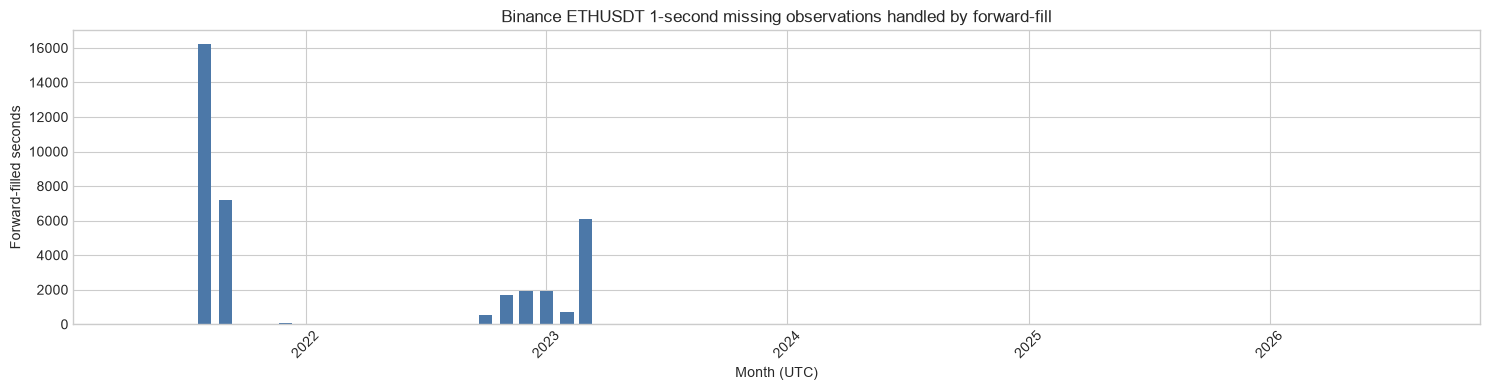

In [10]:
display(missing_by_month)

fig, ax = plt.subplots(figsize=(15, 4))
ax.bar(
    missing_by_month["month"],
    missing_by_month["forward_filled_seconds"],
    width=20,
    color="#4C78A8",
)
ax.set(
    title="Binance ETHUSDT 1-second missing observations handled by forward-fill",
    xlabel="Month (UTC)",
    ylabel="Forward-filled seconds",
)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



## 6. Position lifetime 결과

- `terminal_return_fee_inclusive`: lifetime Collect fee 포함, gas 제외
- `terminal_return_fee_exclusive`: principal만 사용, fee와 gas 제외
- `il_return_vs_hodl_fee_exclusive`: 실제 회수 principal과 HODL 비교
- `lvr_qv_*`: 논문 QV 근사, loss-positive
- `realized_core_pl_r0_*`: 원 논문의 PL 부호(손실이면 음수), 여기서는 `-LVR`
- `expected_core_pl_r0_*`: entry 이전 30개 일별 log return의 표준편차 사용
- `sofr_adjusted_pl_*`: core PL에서 동적 WETH inventory의 SOFR 기회비용 차감



In [11]:
position_lifetime_metrics



,token_id,initial_owner,tick_lower,tick_upper,entry_block,entry_timestamp,entry_transaction_hash,exit_block,exit_timestamp,exit_transaction_hash,settlement_block,settlement_timestamp,increase_count,decrease_count,collect_count,creation_count,burn_count,ownership_transfer_count,matched_pool_mint_count,liquidity_increased_raw,liquidity_decreased_raw,liquidity_remaining_raw,deposit_amount0_raw,deposit_amount1_raw,withdraw_principal0_raw,withdraw_principal1_raw,collected_amount0_raw,collected_amount1_raw,fee_amount0_raw,fee_amount1_raw,is_fully_withdrawn,is_nft_burned,is_fee_complete_proven,has_unique_range,has_nonnegative_fee,entry_in_study_window,exit_in_study_window,settlement_in_study_window,has_valid_event_order,is_clean_closed,holding_seconds,holding_days,binance_price_entry_usdt,binance_price_exit_usdt,pool_tick_entry,pool_tick_exit,pool_price_entry_usdt,pool_price_exit_usdt,deposit_weth,deposit_usdt,withdraw_principal_weth,withdraw_principal_usdt,fee_weth,fee_usdt,initial_wealth_usdt,principal_exit_value_usdt,fee_exit_value_usdt,lp_exit_value_usdt,hodl_exit_value_usdt,terminal_return_fee_inclusive,terminal_return_fee_exclusive,terminal_excess_return_vs_hodl_fee_inclusive,il_return_vs_hodl_fee_exclusive,il_loss_fraction_terminal,fee_return_on_initial_wealth,lvr_qv_usdt,lvr_qv_fraction_initial,lvr_qv_gap_excluded_usdt,lvr_qv_gap_excluded_fraction_initial,rebalancing_strategy_value_usdt,lvr_direct_validation_usdt,lvr_direct_validation_fraction_initial,realized_core_pl_r0_usdt,realized_core_pl_r0_fraction_initial,sofr_percent_at_entry,sofr_opportunity_cost_usdt,sofr_opportunity_cost_fraction_initial,sofr_adjusted_pl_usdt,sofr_adjusted_pl_fraction_initial,pre_entry_volatility_30d_daily,pre_entry_volatility_30d_annualized,pl_delta_lower,pl_delta_upper,pl_delta_total,expected_pl_formula_applicable,expected_core_pl_r0_fraction_initial,expected_core_pl_r0_usdt
0,43032,0x61c808d82a3ac53231750dadc13c777b59310bd9,-199800,-198600,12609096,2021-06-10 20:59:06+00:00,0x3cfc1f9447348615d3509fed8291f0947b0abe74857277b8e0339b255476b854,12629754.0,2021-06-14 01:46:25+00:00,0x2ccb68e4337cc67aebaaa7967a21364bbf12c660e4f53d4f9e881361b672501b,12629788.0,2021-06-14 01:55:54+00:00,1,1,1,1,1,0,1,352502420321723597,352502420321723597,0,0,1000000000000,0,999999999999,1642010261468762855,1003817936449,1642010261468762855,3817936450,True,True,True,True,True,True,True,True,True,True,276439.0,3.199525,2466.82,2497.52,-198211,-198081,2467.379918,2499.663633,0.000000,1000000.000000,0.000000,999999.999999,1.642010,3817.936450,1000000.000000,999999.999999,7918.889918,1.007919e+06,1000000.000000,0.007919,-1.000008e-12,0.007919,-1.000008e-12,1.000008e-12,0.007919,12997.861456,0.012998,12997.861456,0.012998,1.012343e+06,12342.852375,0.012343,-12997.861456,-0.012998,0.01,0.047228,4.722836e-08,-12997.908684,-1.299791e-02,0.101578,1.940641,0.152744,-0.039279,0.113465,False,NaN,NaN
1,44929,0x9799b475dec92bd99bbdd943013325c36157f383,-198510,-198500,12619579,2021-06-12 12:12:19+00:00,0x2e784c317518c718d421c7e5347c5609d296b5a9bf1c5d599eca4c490365a76b,12619579.0,2021-06-12 12:12:19+00:00,0x9bf7f089795ea0ff498a051bd88b5d4818a0edd14621abef5862110fe1d1e80e,12619579.0,2021-06-12 12:12:19+00:00,1,1,1,1,1,0,1,3268944060035945759,3268944060035945759,0,0,79999999999,2848817607876838895,73171400250,2850242729241459625,73171400250,1425121364620730,0,True,True,True,True,True,True,True,True,True,True,0.0,0.000000,2409.24,2409.24,-198501,-198501,2396.856952,2396.856952,0.000000,79999.999999,2.848818,73171.400250,0.001425,0.000000,79999.999999,80034.885584,3.433459,8.003832e+04,79999.999999,0.000479,4.360698e-04,0.000479,4.360698e-04,-4.360698e-04,0.000043,0.000000,0.000000,0.000000,0.000000,8.000000e+04,-34.885585,-0.000436,-0.000000,-0.000000,0.01,0.000000,0.000000e+00,-0.000000,-0.000000e+00,0.100276,1.915773,0.000900,0.000100,0.001000,True,0.000000,0.000000
2,45713,0x9799b475dec92bd99bbdd943013325c36157f383,-198830,-198820,12624466,2021-06-13 06:23:28+00:00,0x8c433e7bb34878ceb25f

In [12]:
metric_distribution = position_lifetime_metrics[
    [
        "holding_days",
        "terminal_return_fee_inclusive",
        "terminal_return_fee_exclusive",
        "il_loss_fraction_terminal",
        "lvr_qv_fraction_initial",
        "lvr_qv_gap_excluded_fraction_initial",
        "realized_core_pl_r0_fraction_initial",
        "expected_core_pl_r0_fraction_initial",
        "sofr_opportunity_cost_fraction_initial",
        "sofr_adjusted_pl_fraction_initial",
    ]
].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
metric_distribution



,holding_days,terminal_return_fee_inclusive,terminal_return_fee_exclusive,il_loss_fraction_terminal,lvr_qv_fraction_initial,lvr_qv_gap_excluded_fraction_initial,realized_core_pl_r0_fraction_initial,expected_core_pl_r0_fraction_initial,sofr_opportunity_cost_fraction_initial,sofr_adjusted_pl_fraction_initial
count,1164.000000,1.164000e+03,1164.000000,1.164000e+03,1164.000000,1164.000000,1164.000000,799.000000,1.164000e+03,1.164000e+03
mean,5.630230,1.967381e-03,-0.002496,3.562380e-03,0.004065,0.004065,-0.004065,-0.003916,3.530183e-04,-4.418327e-03
std,66.720336,4.761535e-02,0.028316,1.258078e-02,0.036043,0.036043,0.036043,0.034594,4.188135e-03,3.974004e-02
min,0.000000,-4.310431e-01,-0.481967,-2.249863e-03,0.000000,0.000000,-1.165147,-0.862659,0.000000e+00,-1.272504e+00
1%,0.000000,-9.208812e-02,-0.111658,-1.696551e-04,0.000000,0.000000,-0.058749,-0.068369,0.000000e+00,-6.123896e-02
5%,0.000000,-1.397089e-02,-0.023319,-2.176730e-05,0.000000,0.000000,-0.014063,-0.010311,0.000000e+00,-1.505196e-02
25%,0.000000,-1.110630e-08,-0.000157,-1.759654e-06,0.000000,0.000000,-0.000970,-0.000898,0.000000e+00,-9.919724e-04
50%,0.001667,5.301202e-06,0.000001,1.776195e-16,0.000000,0.000000,-0.000000,0.000000,1.375851e-08,-1.149037e-07
75%,0.319410,2.750716e-04,0.000034,7.751495e-04,0.000970,0.000970,0.000000,0.000000,6.004785e-06,0.000000e+00
95%,10.302375,2.227171e-02,0.013555,1.659599e-02,0.014063,0.014063,-0.000000,0.000000,4.344365e-04,-0.000000e+00


## 7. 전체 분석기간 일별 대표 시계열

이것은 **pool 전체 TVL의 시계열이 아니라**, 그 날짜에 한 번이라도 존재한 clean
closed position 표본을 초기자본으로 가중한 position-day 대표값이다. 따라서 표본
구성의 진입·청산으로 선이 점프할 수 있다. clean 여부는 미래의 NFT burn까지
확인한 사후 표본이므로 실제 투자 가능한 실시간 portfolio로 해석하면 안 된다.

일별 IL/LVR/PL 경로는 fee와 gas를 제외한다. fee-inclusive 값은 lifetime terminal
return에서만 정확히 계산했으며, fee를 보유기간에 선형 배분하지 않았다.



In [13]:
clean_position_portfolio_daily



,date,ethusdt_close,position_day_count,initial_capital_usdt,capital_weighted_il_loss_pct,capital_weighted_lvr_loss_pct,capital_weighted_lvr_gap_excluded_loss_pct,capital_weighted_realized_core_pl_r0_pct,capital_weighted_sofr_opportunity_cost_pct,capital_weighted_sofr_adjusted_pl_pct,capital_weighted_sofr_adjusted_pl_loss_pct,sofr_percent
0,2021-05-05 00:00:00+00:00,3524.26,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01
1,2021-05-06 00:00:00+00:00,3489.73,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01
2,2021-05-07 00:00:00+00:00,3479.53,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01
3,2021-05-08 00:00:00+00:00,3910.26,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01
4,2021-05-09 00:00:00+00:00,3923.95,0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...
1927,2026-08-14 00:00:00+00:00,1882.20,6,29870.879053,0.032581,0.073946,0.073946,-0.073946,0.001410,-0.075355,0.075355,3.62
1928,2026-08-15 00:00:00+00:00,1882.64,1,4961.101827,0.207761,0.198466,0.198466,-0.198466,0.007712,-0.206178,0.206178,3.62
1929,2026-08-16 00:00:00+00:00,1876.00,1,4961.101827,0.069868,0.334663,0.334663,-0.334663,0.013076,-0.347739,0.347739,3.62
1930,2026-08-17 00:00:00+00:00,1913.60,8,39908.536195,0.182957,0.100568,0.100568,-0.100568,0.002433,-0.103002,0.103002,3.66


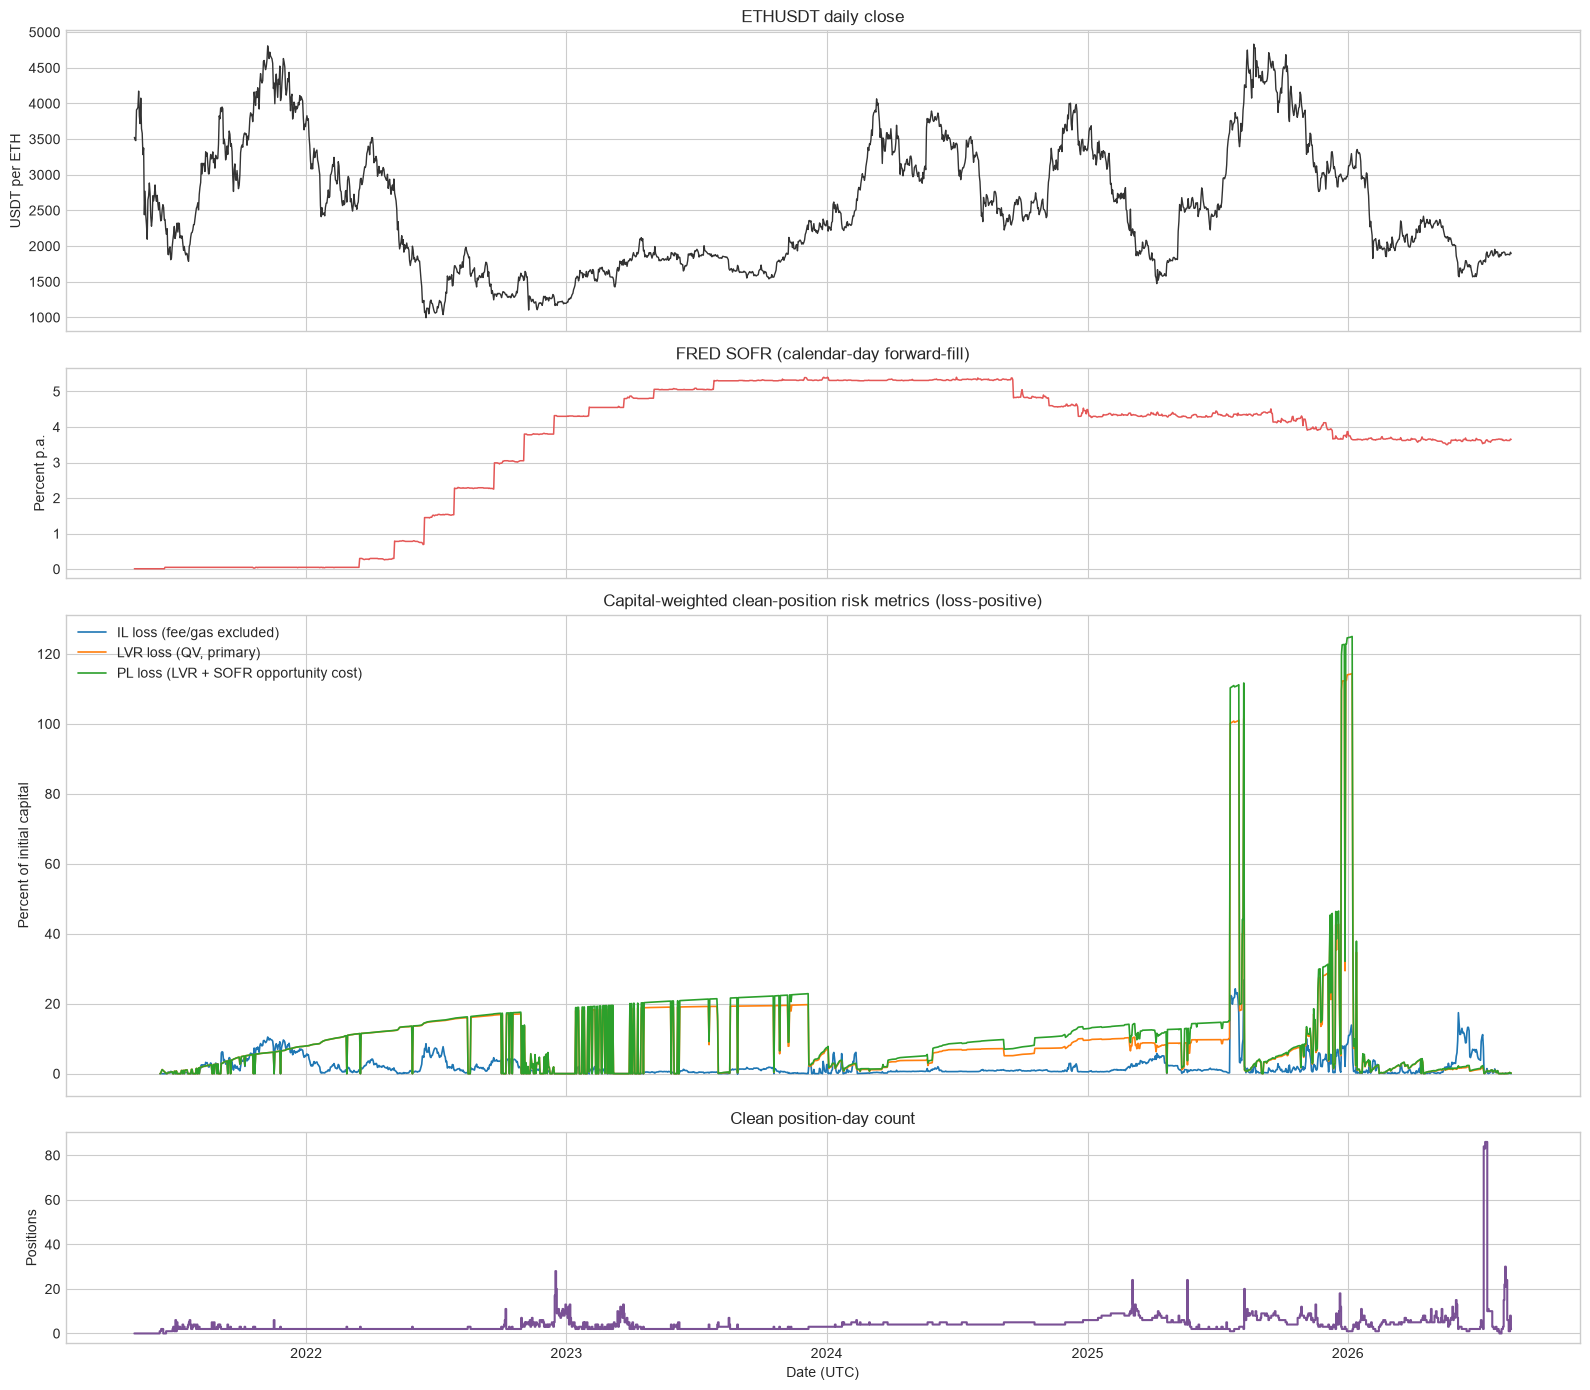

In [14]:
plot_data = clean_position_portfolio_daily.loc[
    clean_position_portfolio_daily["position_day_count"] > 0
].copy()

fig, axes = plt.subplots(
    4,
    1,
    figsize=(16, 14),
    sharex=True,
    gridspec_kw={"height_ratios": [1.0, 0.7, 1.6, 0.7]},
)

axes[0].plot(
    clean_position_portfolio_daily["date"],
    clean_position_portfolio_daily["ethusdt_close"],
    color="#333333",
    linewidth=1.0,
)
axes[0].set(title="ETHUSDT daily close", ylabel="USDT per ETH")

axes[1].plot(
    clean_position_portfolio_daily["date"],
    clean_position_portfolio_daily["sofr_percent"],
    color="#E45756",
    linewidth=1.1,
)
axes[1].set(title="FRED SOFR (calendar-day forward-fill)", ylabel="Percent p.a.")

axes[2].plot(
    plot_data["date"],
    plot_data["capital_weighted_il_loss_pct"],
    label="IL loss (fee/gas excluded)",
    linewidth=1.2,
)
axes[2].plot(
    plot_data["date"],
    plot_data["capital_weighted_lvr_loss_pct"],
    label="LVR loss (QV, primary)",
    linewidth=1.2,
)
axes[2].plot(
    plot_data["date"],
    plot_data["capital_weighted_sofr_adjusted_pl_loss_pct"],
    label="PL loss (LVR + SOFR opportunity cost)",
    linewidth=1.2,
)
axes[2].set(
    title="Capital-weighted clean-position risk metrics (loss-positive)",
    ylabel="Percent of initial capital",
)
axes[2].legend(loc="best")

axes[3].step(
    clean_position_portfolio_daily["date"],
    clean_position_portfolio_daily["position_day_count"],
    where="mid",
    color="#7A5195",
)
axes[3].set(xlabel="Date (UTC)", ylabel="Positions", title="Clean position-day count")

plt.tight_layout()
plt.show()



## 8. 다음 단계로 확장할 때

현재 clean 표본은 계산 정의를 검증하기 위한 첫 단계다. 전체 position으로 확장할 때는
다음을 별도로 구현해야 한다.

1. 여러 Increase/Decrease마다 liquidity와 cost basis를 event 순서대로 갱신
2. NFT ownership transfer 전후의 귀속수익 분리
3. 아직 열려 있는 position의 right-censoring과 분석종료 mark-to-market
4. 부분회수 position의 realized/unrealized return 분리
5. Collect 시각을 이용한 fee accrual path와 실제 gas 비용 결합
6. SOFR를 전체 LP principal에 적용하는 cash-benchmark PL을 별도 민감도로 추가
7. short/mid/long 및 ETH 상승/횡보/하락 regime의 대표 position 선정



In [15]:
output_files = pd.DataFrame(
    {
        "file": [
            "clean_closed_positions.parquet",
            "position_lifetime_metrics.parquet",
            "clean_position_portfolio_daily.parquet",
        ],
        "path": [
            str(OUTPUT_ROOT / "clean_closed_positions.parquet"),
            str(OUTPUT_ROOT / "position_lifetime_metrics.parquet"),
            str(OUTPUT_ROOT / "clean_position_portfolio_daily.parquet"),
        ],
    }
)
display(output_files)

scratch.cleanup()
print("Temporary decoded event cache removed; original data was not modified.")


,file,path
0,clean_closed_positions.parquet,..\..\data_processing\clean_closed_positions.parquet
1,position_lifetime_metrics.parquet,..\..\data_processing\position_lifetime_metrics.parquet
2,clean_position_portfolio_daily.parquet,..\..\data_processing\clean_position_portfolio_daily.parquet


Temporary decoded event cache removed; original data was not modified.
